# Marketplace Safety - Prioritization of Suspicious Listings and Messages

**Background**  
This project was carried out on behalf of the analytics team at a company that operates a marketplace app.  
The platform is used daily by a large number of users, the vast majority of whom are genuine. However, every week a small proportion of problematic activity occurs: scam listings, spam, suspicious accounts acting quickly and attempts to move conversations off the platform.

**Problem**  
The company's Trust & Safety team manually reviews and handles suspicious content. The problem is that the volume is too large for the team to review everything in time. Management is therefore requesting a decision-support tool that helps the team prioritize what to review first.

**Goal**  
The goal of this project is to build a machine learning model that supports the Trust & Safety team by automatically scoring and ranking listings by suspicion level. The solution must:
- performs reasonably well on new data
- can be run regularly in production
- can be explained to non-technical stakeholders

The focus is on prioritization and decision support.

**Stakeholder**  
The primary stakeholder is the COO, who balances two competing operational costs:
- the **review cost**: staff time spent investigating flagged listings
- the **miss cost**: reputational and user harm caused by undetected scams

Kolumnnamn | Förklaring |
|---|---|
| `id` | Unikt identifieringsnummer för varje post |
| `day` | Dagen då händelsen inträffade |
| `event_type` | Typ av händelse (t.ex. visning, meddelande, anmälan) |
| `category` | Produktkategori för annonsen |
| `region` | Geografiskt område där annonsen publicerades |
| `device` | Enhetstyp som användes (t.ex. mobil, dator) |
| `account_age_days` | Antal dagar sedan kontot skapades |
| `num_prev_listings` | Antal tidigare annonser från samma användare |
| `prev_reports_30d` | Antal gånger användaren anmälts de senaste 30 dagarna |
| `verification_level` | Verifieringsnivå för kontot |
| `price` | Annonsens pris |
| `num_images` | Antal bilder i annonsen |
| `message_length` | Längden på meddelandet i annonsen |
| `contains_off_platform` | Om användaren försökt flytta konversationen utanför plattformen |
| `urgency_words` | Om annonsen innehåller ord som skapar artificiell brådska |
| `payment_attempt` | Om ett betalningsförsök har skett |
| `time_to_first_response_min` | Tid i minuter till första svar |
| `is_suspicious` | Målvariabel — om annonsen är misstänkt (1) eller inte (0) |

In [47]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, 
    cross_val_predict, 
    GridSearchCV, 
    cross_validate
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier


from sklearn.metrics import (
    accuracy_score, 
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(palette="rocket")

## Data understanding & EDA

### Summary

The dataset contains 12,000 records and 18 features, including numerical variables and categorical variables. The target variable is `is_suspicious`, a binary label indicating whether a listing has been flagged as suspicious (1) or legitimate (0).  

**Missing values**  
Three features contain missing values:   
- `region` (340)  
- `price` (818)  
- `time_to_first_response_min` (590)  

These are handled in the preprocessing pipeline using `SimpleImputer` with median imputation for numerical features and a constant "Unknown" fill for categorical ones. I will add a missing indicator to preserve the information that a value was absent.  

**Target distribution**  
The dataset is imbalanced: 89.8% of listings are legitimate and 10.2% are suspicious. This means a naive model that always predicts "legitimate" would achieve 90% accuracy while catching zero scams. To address this `class_weight="balanced"` will be applied to all models during training.  

**Correlation with target**  
The strongest positive correlations with `is_suspicious` are:  
- `contains_off_platform` (0.14): attempts to move conversations off the platform  
- `prev_reports_30d` (0.13): recent reports against the user  
- `urgency_words` (0.09): artificial urgency in the listing text  

The strongest negative correlations are:  
- `account_age_days` (-0.10): newer accounts are more suspicious  
- `verification_level` (-0.10): less verified accounts are more suspicious

In [48]:
marketplace_data = pd.read_csv("../Data/historical_data.csv")

print(marketplace_data.shape)
marketplace_data.head()

(12000, 18)


,id,day,event_type,category,region,device,account_age_days,num_prev_listings,prev_reports_30d,verification_level,price,num_images,message_length,contains_off_platform,urgency_words,payment_attempt,time_to_first_response_min,is_suspicious
0,0,8,ad_post,other,urban,android,38.4,2,1,1,594.16,3,91,0,1,0,2.3,0
1,1,4,ad_post,fashion,urban,android,20.0,1,0,1,134.47,2,150,0,0,0,13.6,0
2,2,4,ad_post,other,metro,ios,46.7,3,1,1,198.52,3,72,0,0,0,4.2,0
3,3,3,ad_post,furniture,metro,android,44.3,3,1,2,141.20,3,0,0,0,0,19.8,0
4,4,1,ad_post,electronics,metro,web,211.2,5,0,0,81.39,3,9,0,0,1,23.3,0


In [49]:
marketplace_data.describe().T

,count,mean,std,min,25%,50%,75%,max
id,12000.0,5999.500000,3464.245950,0.00,2999.750,5999.500,8999.250,11999.00
day,12000.0,7.482667,4.032520,1.00,4.000,7.000,11.000,14.00
account_age_days,12000.0,99.632567,112.903541,2.20,36.300,66.600,120.700,2741.70
num_prev_listings,12000.0,3.027750,1.766467,0.00,2.000,3.000,4.000,12.00
prev_reports_30d,12000.0,0.151500,0.386083,0.00,0.000,0.000,0.000,3.00
verification_level,12000.0,0.710167,0.719171,0.00,0.000,1.000,1.000,2.00
price,11182.0,207.348603,196.226023,7.67,86.195,149.225,256.795,2743.08
num_images,12000.0,2.870417,1.766886,0.00,2.000,3.000,4.000,10.00
message_length,12000.0,111.154417,66.396885,0.00,63.000,108.000,155.000,416.00
contains_off_platform,12000.0,0.072833,0.259874,0.00,0.000,0.000,0.000,1.00


In [50]:
marketplace_data.dtypes

id                              int64
day                             int64
event_type                        str
category                          str
region                            str
device                            str
account_age_days              float64
num_prev_listings               int64
prev_reports_30d                int64
verification_level              int64
price                         float64
num_images                      int64
message_length                  int64
contains_off_platform           int64
urgency_words                   int64
payment_attempt                 int64
time_to_first_response_min    float64
is_suspicious                   int64
dtype: object

In [51]:
print("Total missing values:\n\n", marketplace_data.isna().sum())
print("\n")
print("Percentage of missing values:\n\n", round(marketplace_data.isnull().sum() / len(marketplace_data) * 100),3)

Total missing values:

 id                              0
day                             0
event_type                      0
category                        0
region                        340
device                          0
account_age_days                0
num_prev_listings               0
prev_reports_30d                0
verification_level              0
price                         818
num_images                      0
message_length                  0
contains_off_platform           0
urgency_words                   0
payment_attempt                 0
time_to_first_response_min    590
is_suspicious                   0
dtype: int64


Percentage of missing values:

 id                            0.0
day                           0.0
event_type                    0.0
category                      0.0
region                        3.0
device                        0.0
account_age_days              0.0
num_prev_listings             0.0
prev_reports_30d              0.0
verificatio

In [52]:
X_full = marketplace_data.drop(["is_suspicious"], axis=1)
y_full = marketplace_data["is_suspicious"]

print("X:", X_full.shape, "\ny:", y_full.shape)

X: (12000, 17) 
y: (12000,)


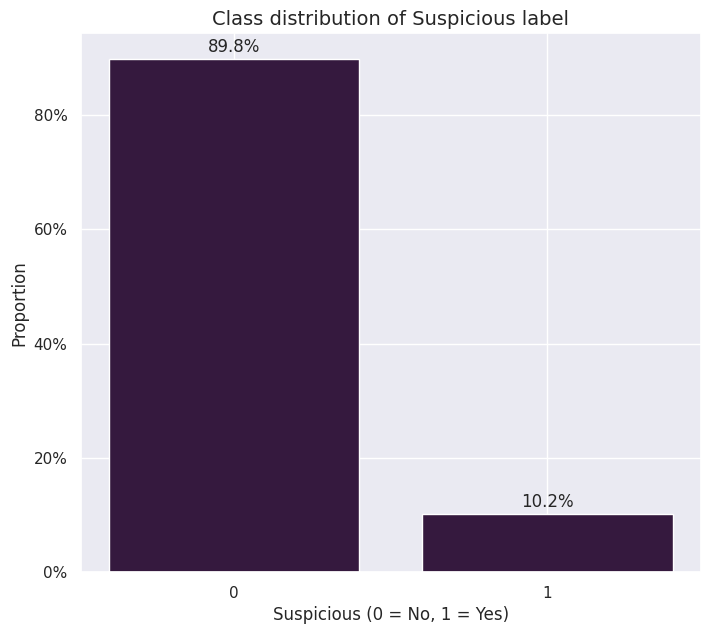

In [53]:
y_distribution = y_full.value_counts(normalize=True)

fig1, ax = plt.subplots(figsize=(8,7))
suspocious_distribution = ax.bar(y_distribution.index, y_distribution.values)

for bar in suspocious_distribution:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.005,
            f'{height:.1%}', ha='center', va='bottom')

ax.set_title("Class distribution of Suspicious label", fontsize=14)
ax.set_xlabel("Suspicious (0 = No, 1 = Yes)")
ax.set_ylabel("Proportion")
ax.set_xticks([0, 1])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

plt.savefig("../Img/fig1_suspicious_share")
plt.show()

In [54]:
correlation_with_target = marketplace_data.copy()

correlation_with_target = (
    correlation_with_target.drop(
        ["event_type", "category", "region", "device"], axis=1)
        .corr()["is_suspicious"]
        .sort_values(ascending=False)
)

display(correlation_with_target)

is_suspicious                 1.000000
contains_off_platform         0.141828
prev_reports_30d              0.130920
urgency_words                 0.087295
payment_attempt               0.066666
price                         0.011883
num_images                    0.009446
id                            0.005236
day                          -0.007565
message_length               -0.011989
time_to_first_response_min   -0.013942
num_prev_listings            -0.015895
verification_level           -0.100409
account_age_days             -0.103146
Name: is_suspicious, dtype: float64

## Train/test split & preprocessing

### Summary

**Train/test split**  
The dataset was split into 80% training (9,600 records) and 20% test (2,400 records) planning to use cross-validation in the model comparison. `stratify=y` was applied to ensure the target distribution remains consistent across both sets (≈90% legitimate, ≈10% suspicious).

**Feature engineering**  
Three new features were engineered based on knowledge about scam behavior:  
- `report_rate` - previous reports normalized by listing count, capturing how often a user is reported relative to their activity level  
- `risk_score` - sum of three behavioral red flags: off-platform contact attempts, urgency words and payment attempts  
- `new_and_reported` - binary flag identifying accounts that are both new (under 30 days) and already reported, a combination associated with scam behavior  

**Preprocessing pipeline**  
- A `ColumnTransformer` pipeline was built separately for numerical and categorical features.  
- Numerical features were imputed with the median and scaled with `StandardScaler`. 
- Categorical features were imputed with a constant "Unknown" and encoded with `OneHotEncoder`.  
All preprocessing is applied inside the pipeline to prevent data leakage.

**Feature engineering impact**  
To validate the engineered features, two pipelines were compared using 5-fold cross-validation on the training set:  

| Metric | Base | Engineered | Difference |
|---|---|---|---|
| accuracy | 0.8224 | 0.8290 | +0.0066 |
| precision | 0.2566 | 0.2711 | +0.0145 |
| recall | 0.3892 | 0.4004 | +0.0112 |
| f1 | 0.3091 | 0.3232 | +0.0140 |
| roc_auc | 0.7405 | 0.7472 | +0.0066 |

The engineered features produced a consistent improvement across all metrics, confirming they add genuine predictive value and justifying their inclusion in the final pipeline.

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X_full,
    y_full,
    test_size=0.20,
    random_state=42,
    stratify=y_full
)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)
print("\n")
print(f"Classification train: \n{y_train.value_counts(normalize=True)}")
print("\n")
print(f"Classification test: \n{y_test.value_counts(normalize=True)}")

Train: (9600, 17) (9600,)
Test: (2400, 17) (2400,)


Classification train: 
is_suspicious
0    0.898021
1    0.101979
Name: proportion, dtype: float64


Classification test: 
is_suspicious
0    0.897917
1    0.102083
Name: proportion, dtype: float64


In [56]:
def engineer_features(X):
    X = X.copy()
    X["report_rate"] = X["prev_reports_30d"] / (X["num_prev_listings"] + 1)
    X["risk_score"]  = X["contains_off_platform"] + X["urgency_words"] + X["payment_attempt"]
    X["new_and_reported"] = ((X["account_age_days"] < 30) & (X["prev_reports_30d"] > 0)).astype(int)

    return X

feature_engineer = FunctionTransformer(engineer_features)

In [57]:
numeric_features_base = [
    "account_age_days", "num_prev_listings", "prev_reports_30d",
    "price", "num_images", "message_length", "verification_level",
    "time_to_first_response_min", "payment_attempt",
    "contains_off_platform", "urgency_words"
]

numeric_features_engineered = numeric_features_base + ["report_rate", "risk_score", "new_and_reported"]

categorical_features = ["event_type", "category", "region", "device"]

In [58]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler",  StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

In [59]:
preprocess_none = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features_base),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

preprocess_engineered = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features_engineered),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

In [60]:
basic_features_pipeline = Pipeline(steps=[
    ("preprocess", preprocess_none),
    ("classifier", RandomForestClassifier(
        class_weight="balanced", n_estimators=200,
        min_samples_leaf=5, max_depth=10, random_state=42))
])

with_engineered_features_pipeline = Pipeline(steps=[
    ("features",   FunctionTransformer(engineer_features)),
    ("preprocess", preprocess_engineered),
    ("classifier", RandomForestClassifier(
        class_weight="balanced", n_estimators=200,
        min_samples_leaf=5, max_depth=10, random_state=42))
])

In [61]:
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

results_base = cross_validate(basic_features_pipeline, X_train, y_train, cv=5, scoring=scoring)
results_engineered = cross_validate(with_engineered_features_pipeline, X_train, y_train, cv=5, scoring=scoring)

rows = []
for metric in scoring:
    base = results_base[f"test_{metric}"].mean()
    eng  = results_engineered[f"test_{metric}"].mean()
    rows.append({"Metric": metric, "Base": round(base, 4), "Engineered": round(eng, 4), "Difference": round(eng - base, 4)})

pd.DataFrame(rows).set_index("Metric")

,Base,Engineered,Difference
Metric,,,
accuracy,0.8224,0.8290,0.0066
precision,0.2566,0.2711,0.0145
recall,0.3892,0.4004,0.0112
f1,0.3091,0.3232,0.0140
roc_auc,0.7405,0.7472,0.0066


## Modeling and comparison

### Summary
Five models were trained and evaluated using 5-fold cross-validation on the training set, all with `class_weight="balanced"` to address the class imbalance. **F1 score** was chosen as the primary metric as it balances precision and recall, which is appropriate for an imbalanced dataset where both false alarms and missed scams have a real cost.

**Results**  
| Model | Accuracy | Precision | Recall | F1 | ROC AUC |
|---|---|---|---|---|---|
| **Random Forest** | **0.829** | **0.271** | **0.399** | **0.323** | **0.747** |
| Logistic Regression | 0.696 | 0.198 | 0.651 | 0.304 | 0.739 |
| Gradient Boosting | 0.791 | 0.229 | 0.441 | 0.301 | 0.721 |
| Decision Tree | 0.677 | 0.185 | 0.636 | 0.286 | 0.715 |
| Dummy | 0.898 | 0.000 | 0.000 | 0.000 | 0.500 |

Random Forest achieved the highest F1 (0.323) and ROC AUC (0.747), making it the best 
overall model. The relatively low F1 scores across all models are expected given the 
synthetic nature of the dataset, where boundaries between suspicious and legitimate 
listings are less sharp than in real-world data.

As Random Forest and Logistic regression were the best two models, they were selected as for hyperparameter tuning.

In [62]:
models = {
    "Dummy": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced", min_samples_leaf=5, max_depth=10),
    "Gradient Boosting": HistGradientBoostingClassifier(random_state=42, class_weight="balanced")
}

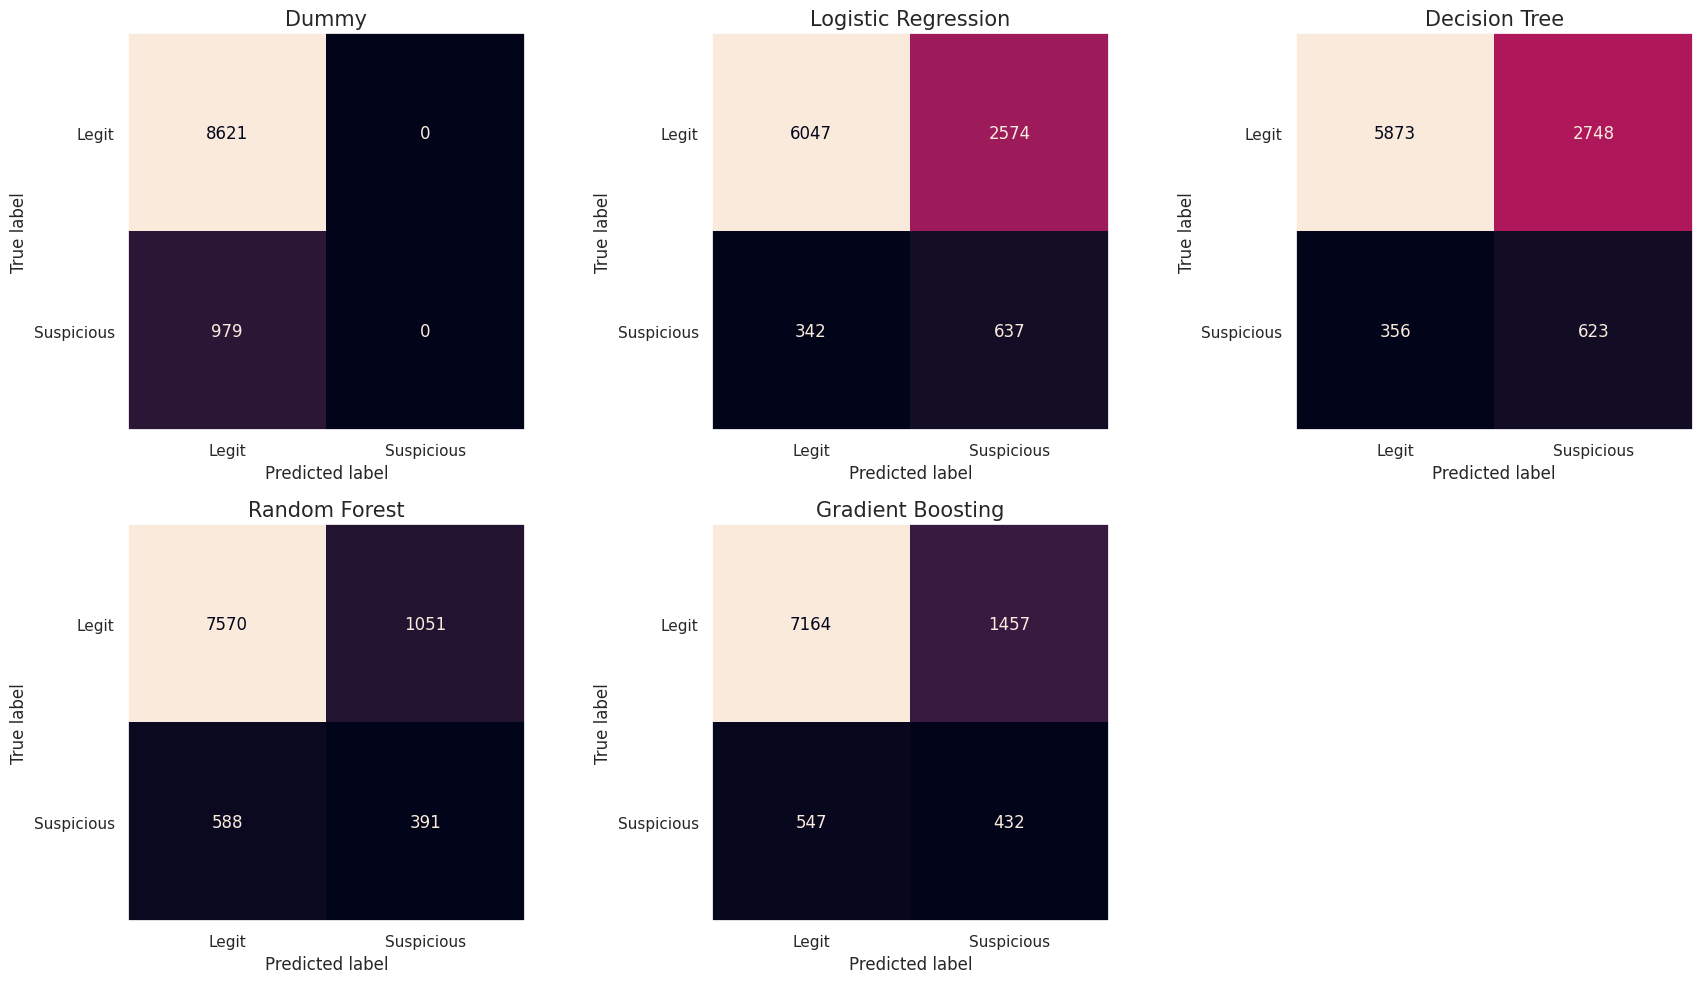

,model,accuracy,precision,recall,f1,roc_auc
3,Random Forest,0.829271,0.271151,0.399387,0.323007,0.746928
1,Logistic Regression,0.696250,0.198381,0.650664,0.304057,0.738979
4,Gradient Boosting,0.791250,0.228692,0.441267,0.301255,0.720598
2,Decision Tree,0.676667,0.184812,0.636364,0.286437,0.715378
0,Dummy,0.898021,0.000000,0.000000,0.000000,0.500000


In [63]:
# Building one pipeline for each model
pipelines = {}

for name, model in models.items():
    pipelines[name] = Pipeline(steps=[
        ("feature_engineer", feature_engineer),
        ("preprocessor", preprocess_engineered),
        ("classifier", model)
    ])

# Evaluating each model with cross_val_predict and showing the confusion matrix for each model
rows = []

fig2, axes = plt.subplots(2, 3, figsize=(18,10))
axes_flat = axes.flatten()
axes_flat[5].set_visible(False)

for idx, (name, pipeline) in enumerate (pipelines.items()):
    y_pred = cross_val_predict(pipeline, X_train, y_train, cv=5, n_jobs=-1)

    y_proba = cross_val_predict(
        pipeline,
        X_train,
        y_train,
        cv=5,
        n_jobs=-1,
        method="predict_proba"
    )[:, 1]

    rows.append({
        "model": name,
        "accuracy": accuracy_score(y_train, y_pred),
        "precision": precision_score(y_train, y_pred, zero_division=0),
        "recall": recall_score(y_train, y_pred, zero_division=0),
        "f1": f1_score(y_train, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_train, y_proba)
    })

    cm = confusion_matrix(y_train, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Legit", "Suspicious"])
    disp.plot(ax=axes_flat[idx], colorbar=False, cmap="rocket")
    axes_flat[idx].grid(False)
    axes_flat[idx].set_title(name, size=15)

plt.tight_layout()
plt.savefig("../Img/fig2_conf_matrix_all_models")
plt.show()

results_cv = pd.DataFrame(rows).sort_values("f1", ascending=False)
display(results_cv)

## Hyperparameter tuning

### Summary  

To ensure a fair model comparison, both Logistic Regression and Random Forest were tuned using `GridSearchCV` with 5-fold cross-validation, optimizing for F1 score.

**Logistic Regression** was searched over regularization strength (`C`), penalty type (`l1/l2`) and solver (`lbfgs/saga`). The best configuration used `C=0.1` with L1 regularization, indicating that a simpler, more constrained model performs better on this dataset.  
Best F1: **0.309**.

**Random Forest** was searched over tree depth (`max_depth`), minimum samples per leaf (`min_samples_leaf`) and number of trees (`n_estimators`). The best configuration used `max_depth=10`, `min_samples_leaf=10` and `n_estimators=300`, confirming that limiting tree complexity is essential for handling the class imbalance.  
Best F1: **0.329**.

Random Forest was selected as the final model based on its superior and consistent F1 score across all evaluation stages.

In [64]:
logreg_params = {
    "classifier__penalty": ["l1", "l2"],
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__solver": ["lbfgs", "saga"]
}

rf_params = {
    "classifier__max_depth": [5, 10, 15],
    "classifier__min_samples_leaf": [3, 5, 10],
    "classifier__n_estimators": [100, 200, 300]
}

logreg_search = GridSearchCV(pipelines["Logistic Regression"], logreg_params, cv=5, scoring="f1")
rf_search = GridSearchCV(pipelines["Random Forest"], rf_params, cv=5, scoring="f1")

logreg_search.fit(X_train, y_train)
rf_search.fit(X_train, y_train)

print(f"Best LogReg F1:, {round(logreg_search.best_score_,3)}, {logreg_search.best_params_}")
print("\n")
print(f"Best RF F1:, {round(rf_search.best_score_,3)}, {rf_search.best_params_}")

Best LogReg F1:, 0.309, {'classifier__C': 0.1, 'classifier__penalty': 'l1', 'classifier__solver': 'saga'}


Best RF F1:, 0.329, {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 10, 'classifier__n_estimators': 300}


## Threshold and prioritization based on business context

### Summary  
The assignment required choosing between two strategies: a fixed threshold decision (A) or a Top-X prioritization approach (B). Both were explored before making a final decision.  

#### A - Threshold decision (explored but not adopted)  
The precision/recall tradeoff was analyzed across different probability thresholds to 
understand the consequences of each choice. As shown in the chart, lowering the threshold increases recall (more scams caught) at the cost of precision (more false alarms), while raising it does the opposite.

A threshold of 0.40 was identified as a good balance, catching 70% of scams with an F1 score of 0.31. At this threshold the consequences are:  

- **TP (687):** Real scams correctly flagged for review  
- **FP (2,814):** Legitimate listings wrongly flagged  
- **FN (292):** Real scams missed and remaining on the platform  
- **Recall: 70% | Precision: 20% | F1: 0.31**   

#### B - Daily capacity prioritization (adopted)
Rather than flagging everything above a threshold, the model scores every listing with a risk probability and the team reviews a fixed number of the highest-risk cases each day. This respects the team's operational capacity and ensures the most suspicious listings are always reviewed first.  

The daily capacity was set to **100 listings**. Although a percentage-based capacity (such as top 10%) was explored during development, a fixed daily limit of 100 cases was chosen for the new data deployment. This reflects a realistic operational constraint: the Trust & Safety team has a predictable daily capacity regardless of how many new listings arrive, making a fixed number more practical than a volume-dependent percentage.

At 100 daily cases capacity the model achieves:  

**Training set (960 cases):**  
- **TP (49):** real scams flagged and reviewed
- **FP (51):** legitimate listings wrongly reviewed
- **FN (930):** scams missed, remain on platform until next daily run
- **Precision: 49.00%%**, nearly 1 in 3 flagged cases is a real scam
- **Recall: 5.01%**, limited by the daily capacity constraint
- **F1: 9.08%**

The number of daily cases can be adjusted based on team availability: increased during periods of high platform activity or reduced when staffing is limited.  

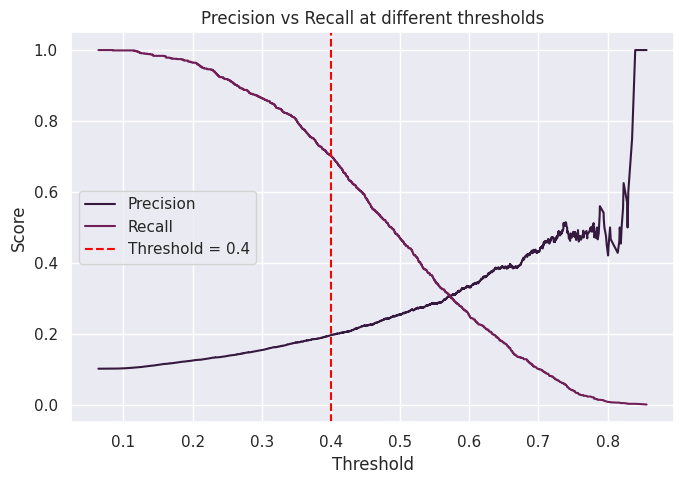

In [65]:
rf_best = rf_search.best_estimator_

y_proba = cross_val_predict(rf_best, X_train, y_train, cv=5, method="predict_proba")[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_train, y_proba)

fig3, ax = plt.subplots(figsize=(7, 5))

ax.plot(thresholds, precisions[:-1], label="Precision")
ax.plot(thresholds, recalls[:-1], label="Recall")
ax.axvline(x=0.4, color="red", linestyle="--", label="Threshold = 0.4")

ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision vs Recall at different thresholds")
plt.legend()
plt.tight_layout()
plt.savefig("../Img/fig3_prec_vs_recall_at_diff_thresholds")
plt.show()

              precision    recall  f1-score   support

       Legit       0.95      0.67      0.79      8621
  Suspicious       0.20      0.70      0.31       979

    accuracy                           0.68      9600
   macro avg       0.57      0.69      0.55      9600
weighted avg       0.88      0.68      0.74      9600



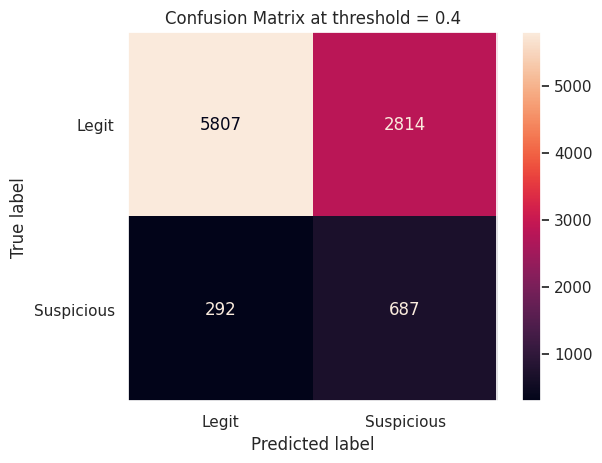

In [66]:
threshold = 0.4

y_pred_threshold = (y_proba >= threshold).astype(int)

print(classification_report(y_train, y_pred_threshold, target_names=["Legit", "Suspicious"]))

cm = confusion_matrix(y_train, y_pred_threshold)
disp = ConfusionMatrixDisplay(cm, display_labels=["Legit", "Suspicious"])
disp.plot(cmap="rocket")
plt.grid(False)
plt.title(f"Confusion Matrix at threshold = {threshold}")
plt.show()

In [67]:
# Error analysis
analysis_df = X_train.copy()
analysis_df["y_true"] = y_train.values
analysis_df["proba_pos"] = y_proba
analysis_df["pred"] = y_pred_threshold
analysis_df["correct"] = (analysis_df["y_true"] == analysis_df["pred"])
analysis_df["confidence"] = np.maximum(analysis_df["proba_pos"], 1 - analysis_df["proba_pos"])

worst_mistakes = (
    analysis_df[analysis_df["correct"] == False]
    .sort_values("confidence", ascending=False)
    .head(10)
)

worst_mistakes[["y_true", "pred", "proba_pos", "confidence"]]

,y_true,pred,proba_pos,confidence
1760,1,0,0.084271,0.915729
9055,1,0,0.114966,0.885034
7435,1,0,0.117529,0.882471
8238,1,0,0.119328,0.880672
6173,1,0,0.121178,0.878822
8050,1,0,0.121951,0.878049
9278,1,0,0.123261,0.876739
10412,1,0,0.123912,0.876088
11409,1,0,0.125376,0.874624
11257,1,0,0.130196,0.869804


In [68]:
def prioritization_report(X, y_true, y_proba, daily_capacity):
    """
    Building prioritization report for a given dataset.

    Parameters:
    - X: feature dataset
    - y_true: true labels
    - y_proba: predicted probs
    - daily_capacity: n of cases to review per day
    """

    df = X.copy()
    df["risk_proba"] = y_proba
    df["true_label"] = y_true.values

    flagged = df.sort_values("risk_proba", ascending=False).head(daily_capacity)

    TP = flagged["true_label"].sum()
    FP = daily_capacity - TP
    FN = y_true.sum() - TP
    TN = len(y_true) - TP - FP - FN
    precision = TP / daily_capacity
    recall = TP / y_true.sum()
    f1 = 2 * (precision * recall) / (precision + recall)
    random_baseline = y_true.sum() / len(y_true) * daily_capacity

    print(f"Flagged: {daily_capacity}")
    print(f"Scams caught (TP): {TP} of {y_true.sum()}")
    print(f"False alarms (FP): {FP} - legit listings wrongly flagged")
    print(f"Missed scams (FN): {FN} - real scams not reviewed")
    print(f"Recall: {recall:.2%}")
    print(f"Precision: {precision:.2%}")
    print(f"F1: {f1:.2%}")
    print(f"Improvement over random: {TP / random_baseline:.1f}x")

In [76]:
# On train set
daily_capacity_train = 100
prioritization_report(X_train, y_train, y_proba, daily_capacity_train)

Flagged: 100
Scams caught (TP): 49 of 979
False alarms (FP): 51 - legit listings wrongly flagged
Missed scams (FN): 930 - real scams not reviewed
Recall: 5.01%
Precision: 49.00%
F1: 9.08%
Improvement over random: 4.8x


## Final test on test set

### Summary  
The final optimized Random Forest was evaluated on the held-out test set (2400 records) that was not used at any point during training or tuning.

Train and test results are very similar confirming the model generalizes well to unseen data with no signs of overfitting.  

**Prioritization on test set**  
Using the 100 daily cases capacity strategy on the test set I achieved:  

- **TP (39):** real scams flagged and reviewed
- **FP (61):** legitimate listings wrongly reviewed
- **FN (206):** scams missed, remain on platform until next daily run
- **Precision: 39.00%**, 1 in 3 flagged cases is a real scam
- **Recall: 15.92%**, limited by the daily capacity constraint
- **F1: 22.61%**

Results are consistent with the training set evaluation, confirming the prioritization 
strategy is stable and reliable on unseen data.

In [77]:
# best_estimator_ is already refitted on the full X_train by GridSearchCV
final_model = rf_search.best_estimator_

y_proba_test = final_model.predict_proba(X_test)[:, 1]

y_pred_test = (y_proba_test >= 0.4).astype(int)

print("Testing results\n", classification_report(y_test, y_pred_test, target_names=["Legit", "Suspicious"]))
print("\n")
print("Training results\n", classification_report(y_train, y_pred_threshold, target_names=["Legit", "Suspicious"]))

Testing results
               precision    recall  f1-score   support

       Legit       0.95      0.68      0.79      2155
  Suspicious       0.20      0.70      0.31       245

    accuracy                           0.68      2400
   macro avg       0.58      0.69      0.55      2400
weighted avg       0.88      0.68      0.74      2400



Training results
               precision    recall  f1-score   support

       Legit       0.95      0.67      0.79      8621
  Suspicious       0.20      0.70      0.31       979

    accuracy                           0.68      9600
   macro avg       0.57      0.69      0.55      9600
weighted avg       0.88      0.68      0.74      9600



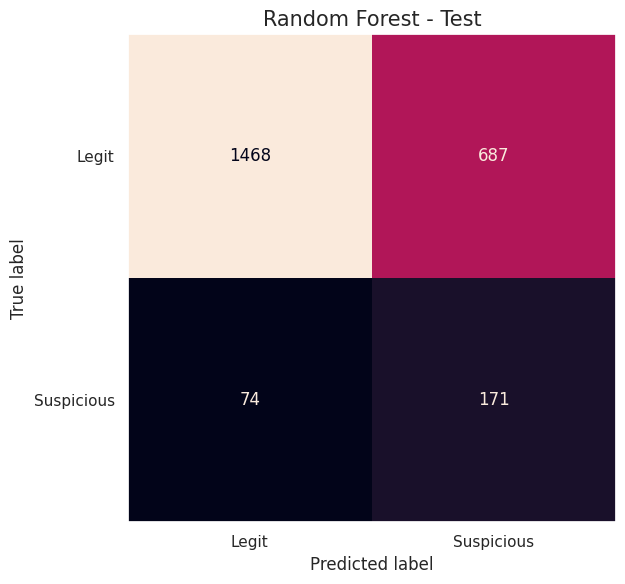

In [71]:
fig4, ax = plt.subplots(figsize=(8, 6))

cm_test = confusion_matrix(y_test, y_pred_test)

disp = ConfusionMatrixDisplay(cm_test, display_labels=["Legit", "Suspicious"])
disp.plot(ax=ax, colorbar=False, cmap="rocket")

ax.set_title("Random Forest - Test", fontsize=15)
ax.grid(False)

plt.tight_layout()
plt.savefig("../Img/fig4_conf_matrix_rf_test")
plt.show()

In [78]:
# On test set
daily_capacity_test = 100

prioritization_report(X_test, y_test, y_proba_test, daily_capacity_test)

Flagged: 100
Scams caught (TP): 39 of 245
False alarms (FP): 61 - legit listings wrongly flagged
Missed scams (FN): 206 - real scams not reviewed
Recall: 15.92%
Precision: 39.00%
F1: 22.61%
Improvement over random: 3.8x


## Deploy test: new data (Tuesday 17/03/2026)

### Summary
The final model was applied to a new unlabelled dataset of 2000 listings, simulating a real production run. Since no true labels are available, performance metrics such as recall and precision cannot be calculated. The model simply scores and ranks each listing by suspicion level.

Of the 2000 new listings, the top 100 highest-risk cases were flagged for the Trust & Safety team to review. The prioritized list `top_cases` contains the most suspicious listings ranked at the top, with a minimum risk probability of 0.691, meaning every case in today's review queue was flagged with high confidence by the model.

In [79]:
new_data = pd.read_csv("../Data/new_data.csv")

y_proba_new_data = final_model.predict_proba(new_data)[:, 1]

priority_new = new_data.copy()
priority_new["risk_proba"] = y_proba_new_data
priority_new = priority_new.sort_values("risk_proba", ascending=False).reset_index(drop=True)

daily_capacity = 100
top_cases = priority_new.head(daily_capacity)

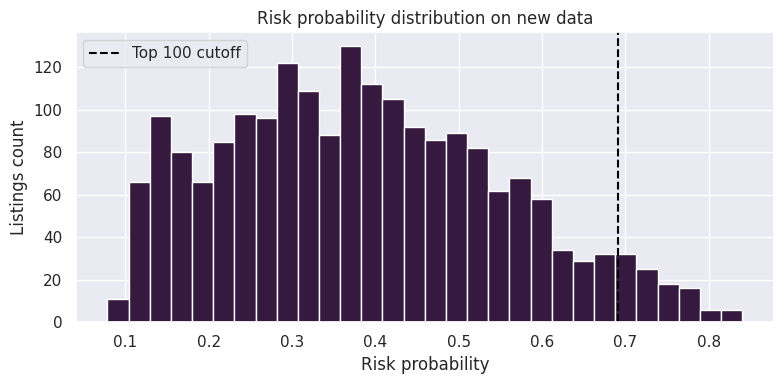

New data size: 2000
Cases above 0.4 probability: 879
Cutoff probability for top 100: 0.691


In [80]:
fig5, ax = plt.subplots(figsize=(8, 4))
ax.hist(y_proba_new_data, bins=30)
ax.axvline(x=top_cases["risk_proba"].min(), color="black", linestyle="--", label=f"Top {daily_capacity} cutoff")
ax.set_xlabel("Risk probability")
ax.set_ylabel("Listings count")
ax.set_title("Risk probability distribution on new data")

plt.tight_layout()
plt.legend()
plt.savefig("../Img/fig5_risk_prob_distribution")
plt.show()

print(f"New data size: {len(new_data)}")
print(f"Cases above 0.4 probability: {(y_proba_new_data > 0.4).sum()}")
print(f"Cutoff probability for top {daily_capacity}: {top_cases["risk_proba"].min():.3f}")

In [75]:
print(f"Top {daily_capacity} highest risk listings:")

display(top_cases[["id", "risk_proba"]])

Top 100 highest risk listings:


,id,risk_proba
0,1831,0.840124
1,1398,0.834834
2,124,0.834556
3,1092,0.834054
4,486,0.833429
...,...,...
95,1719,0.693573
96,118,0.691905
97,1156,0.691512
98,1326,0.691337
